<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/oscillatory_dtb_derministic_ver2_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oscillatory deterministic game: DTB versus explicit Euler

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/dtb_game_dynamics_unnormalized/notebooks/oscillatory_dtb_derministic_ver2.ipynb)

\[
\Phi(x)=-\frac{\lambda}{2}(x_1^2+x_2^2)-\frac{\gamma}{2}(x_1-x_2)^2+
\frac{\varepsilon}{\omega}\{\cos(\omega x_1)+\cos(\omega x_2)\},\qquad \dot x=b(x)=\nabla\Phi(x).
\]
The map \(X(t;z)=T_\theta(z)\) is advanced in a frozen tangent chart:
\[
\alpha^k=\arg\min_\alpha\sum_i\|D_\theta T_\theta(z_i)\alpha-b(X_i^k)\|^2,\qquad
X^{k+1}=X^k+hD_\theta T_\theta\,\alpha^k.
\]
Every `REFIT_INTERVAL` steps, the accumulated tangent map is refitted into \(T_\theta\), after which the tangent bundle is recomputed. Direct explicit Euler with the same \(h\) is the reference, so the plotted discrepancy measures tangent-projection and refit error rather than high-order time-discretization error.

In [1]:
from pathlib import Path
import os, subprocess, sys, math, time
import numpy as np
import matplotlib.pyplot as plt
import torch

REPO = Path("/content/dtb-colab-experiments")
BRANCH = "codex/game-dynamics-dtb"
if not (REPO / ".git").exists():
    subprocess.run(["git","clone","-q","--depth","1","--branch",BRANCH,
                    "https://github.com/sun-mengwei/dtb-colab-experiments.git",str(REPO)],check=True)
else:
    subprocess.run(["git","-C",str(REPO),"checkout","-q",BRANCH],check=True)
    subprocess.run(["git","-C",str(REPO),"pull","-q","--ff-only"],check=True)
sys.path.insert(0,str(REPO/"DTB_rep"))
os.chdir(REPO/"DTB_rep")

try:
    import torch._dynamo.compiled_autograd
except (AttributeError, ImportError):
    pass
from dtb import device, flat_params, jform_solve
from run_game_dtb import ResidualMLPMap, CurrentGameMap, game_dtb_basis_matrices, fit_map_to_target

LAMBDA,GAMMA,EPSILON,OMEGA = 0.5,0.2,0.5,4*math.pi
T,h = 1.0,1e-2
STEPS = round(T/h)
N_PROJ,N_EVAL = 256,512
WIDTH,DEPTH = 12,1
REFIT_INTERVAL = 10
FIT_STEPS,FIT_SAMPLES,FIT_BATCH,FIT_LR = 100,768,256,2e-3
CHUNK,RTOL,SOLVER = 256,1e-5,"svd_gpu"
SEED,MODEL_SEED = 2026,91
DTYPE,DEVICE = torch.float32,device()
if DEVICE.type=="cuda": torch.set_float32_matmul_precision("high")
print({"device":str(DEVICE),"steps":STEPS,"h":h,"projection particles":N_PROJ,
       "evaluation particles":N_EVAL,"refit interval":REFIT_INTERVAL})

{'device': 'cpu', 'steps': 100, 'h': 0.01, 'projection particles': 256, 'evaluation particles': 512, 'refit interval': 10}


In [2]:
def phi(x):
    x1,x2=x.unbind(-1)
    return (-.5*LAMBDA*(x1.square()+x2.square())-.5*GAMMA*(x1-x2).square()
            +(EPSILON/OMEGA)*(torch.cos(OMEGA*x1)+torch.cos(OMEGA*x2)))

def b(x):
    x1,x2=x.unbind(-1)
    return torch.stack((-LAMBDA*x1-GAMMA*(x1-x2)-EPSILON*torch.sin(OMEGA*x1),
                        -LAMBDA*x2-GAMMA*(x2-x1)-EPSILON*torch.sin(OMEGA*x2)),-1)

def uniform(n,g):
    return (2*torch.rand(n,2,generator=g,dtype=DTYPE)-1).to(DEVICE)

def euler(z):
    x=z.clone(); hist=[x.cpu()]
    for _ in range(STEPS):
        x=x+h*b(x); hist.append(x.cpu())
    return torch.stack(hist)

def dtb(z_eval):
    torch.manual_seed(MODEL_SEED)
    model=ResidualMLPMap(dim=2,width=WIDTH,depth=DEPTH,activation="tanh",dtype=DTYPE).to(DEVICE)
    theta0,structure,_=flat_params(model)
    sel=torch.arange(theta0.numel(),device=DEVICE)
    proj_gen=torch.Generator().manual_seed(SEED+1)

    def block():
        theta,_,_=flat_params(model)
        z=uniform(N_PROJ,proj_gen)
        yp,Jp,Jf=game_dtb_basis_matrices(theta,sel,z,model,structure,chunk=CHUNK)
        ye,Je,_=game_dtb_basis_matrices(theta,sel,z_eval,model,structure,chunk=CHUNK)
        return theta,yp.detach(),Jp.detach(),Jf.detach(),ye.detach(),Je.detach(),torch.zeros(sel.numel(),device=DEVICE)

    theta,yp,Jp,Jf,ye,Je,s=block()
    hist=[z_eval.cpu()]; residual=[]; refit_steps=[]; refit_rmse=[]
    tic=time.perf_counter()
    for k in range(STEPS):
        xp=yp+h*torch.einsum("ndm,m->nd",Jp,s)
        target=b(xp).reshape(-1)
        alpha=jform_solve(Jf,target,rtol=RTOL,method=SOLVER).detach()
        residual.append(float(torch.linalg.norm(Jf@alpha-target)/(torch.linalg.norm(target)+1e-30)))
        s=s+alpha
        hist.append((ye+h*torch.einsum("ndm,m->nd",Je,s)).cpu())

        if (k+1)%REFIT_INTERVAL==0:
            target_map=CurrentGameMap(theta,sel,s,h,model,structure,chunk=CHUNK)
            rmse=fit_map_to_target(model,target_map,dim=2,low=-1,high=1,n_samples=FIT_SAMPLES,
                                   steps=FIT_STEPS,lr=FIT_LR,batch_size=FIT_BATCH)
            refit_steps.append(k+1); refit_rmse.append(rmse)
            hist[-1]=model(z_eval).detach().cpu()
            if k+1<STEPS: theta,yp,Jp,Jf,ye,Je,s=block()

        if (k+1)%20==0:
            print(f"{k+1:3d}/{STEPS}: residual={residual[-1]:.2e}, refits={len(refit_steps)}")
    print(f"DTB wall time: {(time.perf_counter()-tic)/60:.2f} min")
    return torch.stack(hist),np.asarray(residual),np.asarray(refit_steps),np.asarray(refit_rmse)

# Two exact implementation checks.
q=torch.tensor([[.17,-.31]],device=DEVICE,requires_grad=True)
assert (torch.autograd.grad(phi(q).sum(),q)[0]-b(q)).abs().max()<2e-6
torch.manual_seed(MODEL_SEED)
m=ResidualMLPMap(dim=2,width=WIDTH,depth=DEPTH,activation="tanh",dtype=DTYPE).to(DEVICE)
assert (m(q.detach())-q.detach()).abs().max()==0

 20/100: residual=6.93e-01, refits=2
 40/100: residual=6.20e-01, refits=4
 60/100: residual=6.22e-01, refits=6
 80/100: residual=5.94e-01, refits=8
100/100: residual=4.91e-01, refits=10
DTB wall time: 0.04 min
final RMSE=2.403e-01, final relative RMSE=3.983e-01
median/max projection residual=6.106e-01/6.928e-01
refit RMSE: [0.012 0.012 0.014 0.015 0.017 0.018 0.025 0.026 0.025 0.031]


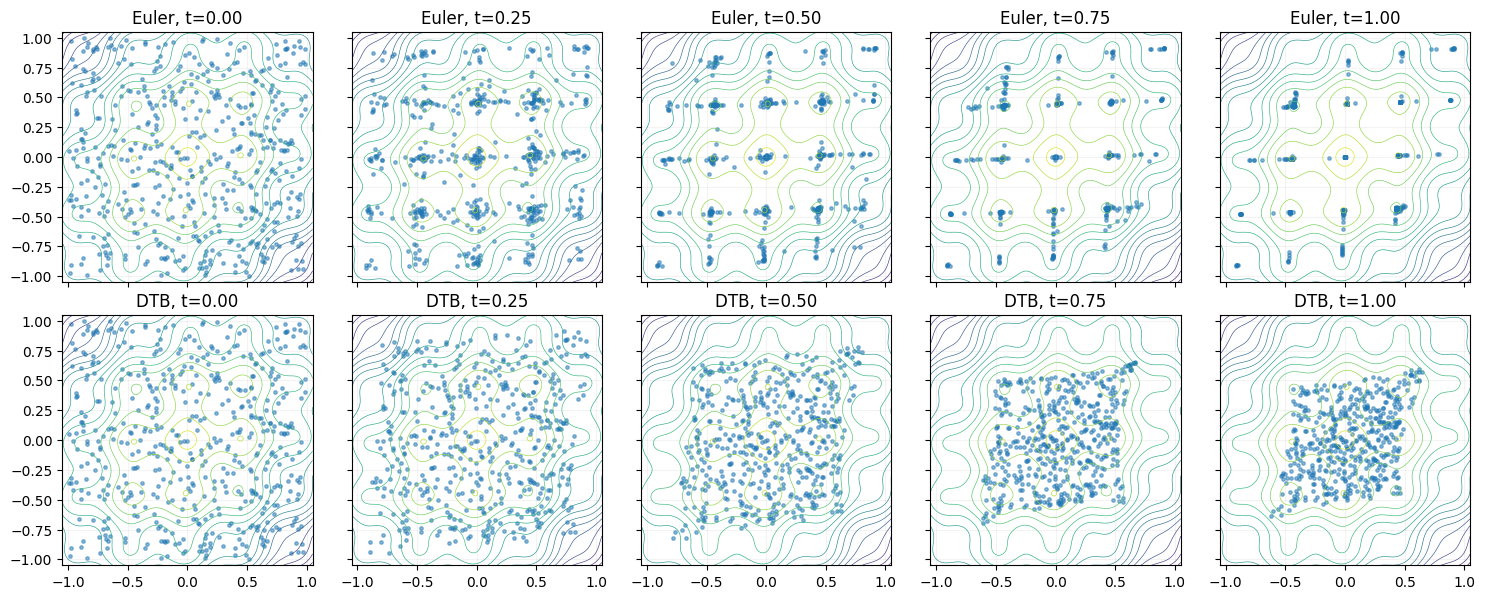

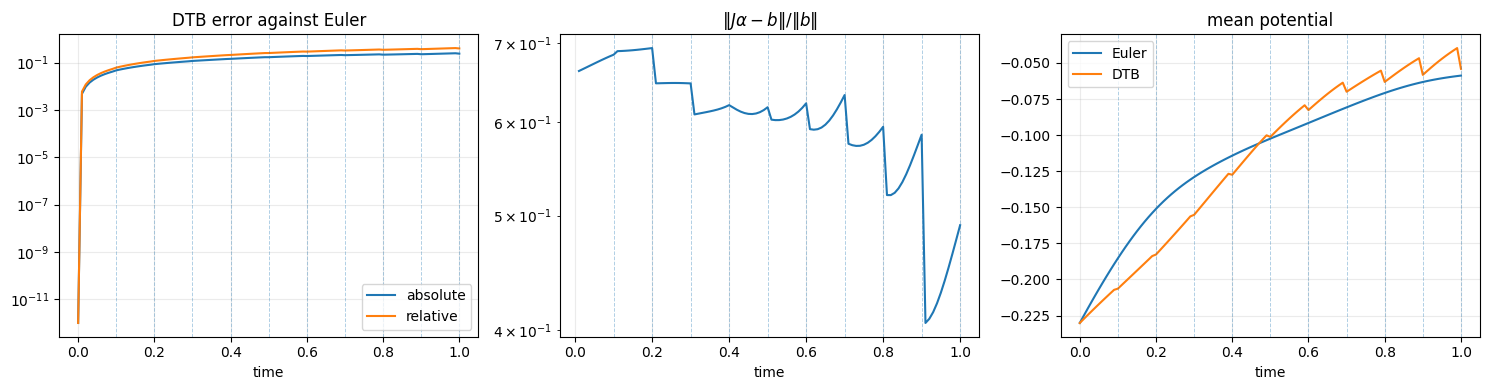

In [3]:
g=torch.Generator().manual_seed(SEED)
z_eval=uniform(N_EVAL,g)
X_euler=euler(z_eval)
X_dtb,residual,refit_steps,refit_rmse=dtb(z_eval)

times=np.arange(STEPS+1)*h
rmse=torch.sqrt(torch.mean(torch.sum((X_dtb-X_euler).square(),-1),-1))
rel=rmse/(torch.sqrt(torch.mean(torch.sum(X_euler.square(),-1),-1))+1e-12)
P_euler=phi(X_euler).mean(1); P_dtb=phi(X_dtb).mean(1)

print(f"final RMSE={rmse[-1]:.3e}, final relative RMSE={rel[-1]:.3e}")
print(f"median/max projection residual={np.median(residual):.3e}/{residual.max():.3e}")
print("refit RMSE:",np.array2string(refit_rmse,precision=3))

snap=np.linspace(0,STEPS,5,dtype=int)
a=torch.linspace(-1.05,1.05,150)
x1,x2=torch.meshgrid(a,a,indexing="xy")
grid=phi(torch.stack((x1.ravel(),x2.ravel()),-1)).reshape(x1.shape).numpy()
fig,ax=plt.subplots(2,5,figsize=(15,6),sharex=True,sharey=True)
for r,(H,name) in enumerate(((X_euler,"Euler"),(X_dtb,"DTB"))):
    for j,k in enumerate(snap):
        p=H[k].numpy(); ax[r,j].contour(x1,x2,grid,levels=16,linewidths=.45)
        ax[r,j].scatter(p[:,0],p[:,1],s=6,alpha=.5)
        ax[r,j].set(title=f"{name}, t={k*h:.2f}",xlim=(-1.05,1.05),ylim=(-1.05,1.05))
        ax[r,j].set_aspect("equal"); ax[r,j].grid(alpha=.15)
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].semilogy(times,rmse+1e-12,label="absolute"); ax[0].semilogy(times,rel+1e-12,label="relative")
ax[0].set_title("DTB error against Euler"); ax[0].legend()
ax[1].semilogy(times[1:],residual+1e-12); ax[1].set_title(r"$\|J\alpha-b\|/\|b\|$")
ax[2].plot(times,P_euler,label="Euler"); ax[2].plot(times,P_dtb,label="DTB")
ax[2].set_title("mean potential"); ax[2].legend()
for a0 in ax:
    a0.set_xlabel("time"); a0.grid(alpha=.25)
    for s in refit_steps: a0.axvline(s*h,ls="--",lw=.7,alpha=.35)
plt.tight_layout(); plt.show()